# Tarea 11 - Clasificación de Texto
### Clasificación de encabezados de noticias con Doc2Vec + SVM

Este notebook implementa un pipeline de clasificación de texto para encabezados de noticias
(dataset **News Aggregator Dataset**, UCI Machine Learning Repository). El flujo de trabajo es:

1. Carga y limpieza del dataset (`newsCorpora-trimmed.csv`)
2. Preprocesamiento de texto (tokenización, minúsculas, eliminación de *stopwords* y signos de puntuación)
3. Representación vectorial de los documentos con **Doc2Vec** (gensim)
4. Entrenamiento de un clasificador **SVM** (kernel lineal) sobre los vectores de documento
5. Evaluación del modelo (accuracy, matriz de confusión, reporte de clasificación)
6. Clasificación de un texto nuevo (ejemplo de inferencia)

Las categorías del dataset son:
- **b** = Business (Negocios)
- **t** = Science and Technology (Ciencia y Tecnología)
- **e** = Entertainment (Entretenimiento)
- **m** = Health (Salud/Medicina)


## 1. Instalación de dependencias

Si no las tienes instaladas, descomenta y ejecuta la siguiente celda una sola vez.

In [1]:
!pip install gensim scikit-learn pandas nltk matplotlib seaborn

     --------------------------------------- 24.4/24.4 MB 12.3 MB/s eta 0:00:00
     ---------------------------------------- 1.7/1.7 MB 15.5 MB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 kB 4.2 MB/s eta 0:00:00
     ---------------------------------------- 80.2/80.2 kB 4.7 MB/s eta 0:00:00
     -------------------------------------- 119.2/119.2 kB 6.8 MB/s eta 0:00:00
     -------------------------------------- 278.0/278.0 kB 8.6 MB/s eta 0:00:00
     ---------------------------------------- 80.7/80.7 kB 4.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Carga de librerías y recursos de NLTK

In [2]:
import time
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Descarga de recursos necesarios de NLTK (solo la primera vez)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\libarra\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\libarra\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\libarra\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## 3. Carga del dataset

El archivo `newsCorpora-trimmed.csv` contiene dos columnas: `category` (etiqueta de la clase)
y `text` (encabezado de la noticia). Se coloca el CSV en la misma carpeta que este notebook.

In [3]:
# Cargar el conjunto de datos
data = pd.read_csv('newsCorpora-trimmed.csv')
data.columns = ['category', 'text']
data = data.dropna(subset=['text', 'category'])

print(f"Total de registros: {len(data)}")
data.head()

Total de registros: 422928


,category,text
0,b,"Fed official says weak data caused by weather,..."
1,b,Fed's Charles Plosser sees high bar for change...
2,b,US open: Stocks fall after Fed official hints ...
3,b,"Fed risks falling 'behind the curve', Charles ..."
4,b,Fed's Plosser: Nasty Weather Has Curbed Job Gr...


📸 **Captura de pantalla #1 para el reporte:** número total de registros cargados y la tabla `head()` con las primeras filas del dataset (columnas `category` y `text`).

In [4]:
# Filtrar solo las categorías de interés
categories = ['b', 't', 'e', 'm']  # Business, Science and Technology, Entertainment, Health (Medicine)
data = data[data['category'].isin(categories)].reset_index(drop=True)

print("Distribución de categorías original:")
print(data['category'].value_counts())

Distribución de categorías original:
category
e    152821
b    115967
t    108501
m     45639
Name: count, dtype: int64


📸 **Captura de pantalla #2 para el reporte:** distribución original de categorías (conteo de `value_counts()`), como evidencia del desbalance de clases antes del muestreo.

### 3.1 Muestreo balanceado

El dataset original tiene más de 420,000 encabezados. Entrenar un SVM sobre todo el conjunto
resulta computacionalmente muy costoso (el tiempo de entrenamiento de SVM crece de forma
cuadrática/cúbica con el número de muestras) y además las clases están desbalanceadas
(hay muchas más noticias de *Entertainment* que de *Health*).

Por esto se toma una muestra aleatoria **balanceada** de un máximo de 6,000 encabezados por
categoría (24,000 en total), lo cual mantiene el problema representativo pero tratable en
tiempo de ejecución razonable.

In [5]:
SAMPLES_PER_CLASS = 6000
RANDOM_STATE = 42

samples = []
for cat in categories:
    subset = data[data['category'] == cat]
    n = min(len(subset), SAMPLES_PER_CLASS)
    samples.append(subset.sample(n=n, random_state=RANDOM_STATE))

data = pd.concat(samples, ignore_index=True)
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)  # mezclar filas

print(f"Total de registros usados: {len(data)}")
print(data['category'].value_counts())

Total de registros usados: 24000
category
b    6000
m    6000
e    6000
t    6000
Name: count, dtype: int64


📸 **Captura de pantalla #3 para el reporte:** total de registros usados después del muestreo balanceado y el conteo por categoría (debe mostrar 6,000 en cada una).

## 4. Preprocesamiento de texto

Para cada encabezado se realiza:
- Conversión a minúsculas
- Tokenización (separación en palabras)
- Eliminación de signos de puntuación (se conservan solo tokens alfabéticos)
- Eliminación de *stopwords* en inglés (palabras muy frecuentes sin valor semántico: *the*, *a*, *is*, ...)


In [6]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

t0 = time.time()
data['tokens'] = data['text'].apply(preprocess_text)
print(f"Tiempo de preprocesamiento: {time.time() - t0:.2f} s")

data[['text', 'tokens']].head()

Tiempo de preprocesamiento: 4.57 s


,text,tokens
0,Passenger jet reportedly crashed in Ukraine,"[passenger, jet, reportedly, crashed, ukraine]"
1,Two infected horses in Interior first signs of...,"[two, infected, horses, interior, first, signs..."
2,Ali Fazal to fly to Abu Dhabi to join 'Fast & ...,"[ali, fazal, fly, abu, dhabi, join, furious, g..."
3,New Clinic for Prostate Cancer In Ghana,"[new, clinic, prostate, cancer, ghana]"
4,Changing how baby is held after birth may cut ...,"[changing, baby, held, birth, may, cut, iron, ..."


📸 **Captura de pantalla #4 para el reporte:** tiempo de preprocesamiento y la tabla `text` / `tokens` mostrando un ejemplo de encabezado antes y después de tokenizar/limpiar.

In [7]:
# Crear documentos etiquetados para Doc2Vec
tagged_data = [TaggedDocument(words=row['tokens'], tags=[row['category']])
               for _, row in data.iterrows()]

print(f"Total de documentos etiquetados: {len(tagged_data)}")
print("Ejemplo:")
print(tagged_data[0])

Total de documentos etiquetados: 24000
Ejemplo:
TaggedDocument<['passenger', 'jet', 'reportedly', 'crashed', 'ukraine'], ['b']>


📸 **Captura de pantalla #5 para el reporte:** total de documentos etiquetados (`TaggedDocument`) y el ejemplo impreso de uno de ellos.

## 5. Entrenamiento del modelo Doc2Vec

Doc2Vec (Le & Mikolov, 2014) aprende una representación vectorial densa de longitud fija
para cada documento, de forma similar a Word2Vec pero a nivel de documento completo.
Parámetros usados:

- `vector_size=100`: dimensión de los vectores de documento
- `window=5`: tamaño de la ventana de contexto
- `min_count=5`: se ignoran palabras que aparecen menos de 5 veces en el corpus
- `epochs=20`: número de pasadas de entrenamiento sobre el corpus

In [8]:
t0 = time.time()

model = Doc2Vec(tagged_data, vector_size=100, window=5, min_count=5, workers=4, epochs=20)

print(f"Tiempo de entrenamiento de Doc2Vec: {time.time() - t0:.2f} s")

# Guardar el modelo
model.save("doc2vec_model")
print("Modelo guardado como 'doc2vec_model'")

Tiempo de entrenamiento de Doc2Vec: 93.14 s
Modelo guardado como 'doc2vec_model'


📸 **Captura de pantalla #6 para el reporte:** tiempo de entrenamiento del modelo Doc2Vec y el mensaje de confirmación de que el modelo se guardó correctamente.

## 6. Vectorización de documentos e inferencia

Una vez entrenado Doc2Vec, se usa `model.infer_vector()` para obtener el vector de cada
documento (esto simula cómo se procesaría un texto nuevo, no visto durante el entrenamiento).

In [9]:
def vectorize_doc(tokens):
    return model.infer_vector(tokens)

t0 = time.time()
data['vector'] = data['tokens'].apply(vectorize_doc)
print(f"Tiempo de vectorización (infer_vector): {time.time() - t0:.2f} s")

Tiempo de vectorización (infer_vector): 30.40 s


📸 **Captura de pantalla #7 para el reporte:** tiempo que tomó vectorizar (inferir) todos los documentos con `infer_vector`.

## 7. División de datos y entrenamiento del clasificador SVM

In [10]:
X = list(data['vector'])
y = data['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Tamaño conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño conjunto de prueba: {len(X_test)}")

Tamaño conjunto de entrenamiento: 19200
Tamaño conjunto de prueba: 4800


📸 **Captura de pantalla #8 para el reporte:** tamaño del conjunto de entrenamiento y de prueba después del `train_test_split`.

In [11]:
t0 = time.time()

classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)

print(f"Tiempo de entrenamiento del SVM: {time.time() - t0:.2f} s")

Tiempo de entrenamiento del SVM: 36.28 s


📸 **Captura de pantalla #9 para el reporte:** tiempo de entrenamiento del clasificador SVM.

## 8. Evaluación del modelo

In [12]:
y_pred = classifier.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print()
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7573

Reporte de clasificación:
              precision    recall  f1-score   support

           b       0.72      0.71      0.71      1200
           e       0.79      0.79      0.79      1200
           m       0.78      0.79      0.79      1200
           t       0.74      0.74      0.74      1200

    accuracy                           0.76      4800
   macro avg       0.76      0.76      0.76      4800
weighted avg       0.76      0.76      0.76      4800



📸 **Captura de pantalla #10 para el reporte (IMPORTANTE):** el valor de `Accuracy` y la tabla completa del `classification_report` (precision, recall, f1-score por clase). Esta es una de las evidencias principales de resultados que debe ir en el reporte.

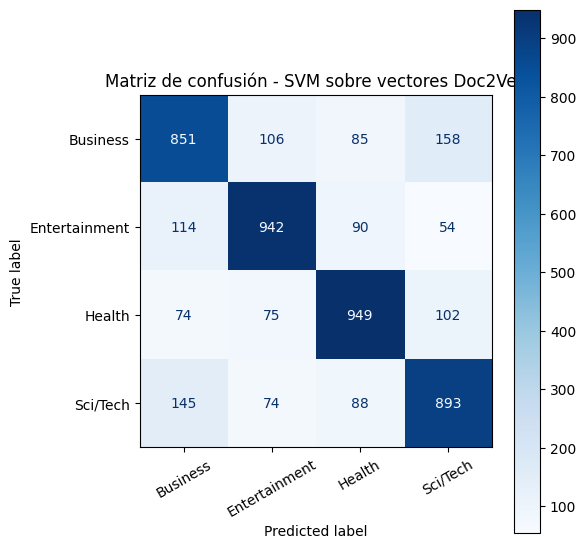

In [13]:
labels = ['b', 'e', 'm', 't']
label_names = {'b': 'Business', 'e': 'Entertainment', 'm': 'Health', 't': 'Sci/Tech'}

cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_names[l] for l in labels])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title("Matriz de confusión - SVM sobre vectores Doc2Vec")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

📸 **Captura de pantalla #11 para el reporte (IMPORTANTE):** la imagen de la **matriz de confusión** generada (también queda guardada como `confusion_matrix.png` en la misma carpeta del notebook, por si prefieres insertar el archivo directamente en Overleaf en vez de una captura).

## 9. Clasificación de un documento nuevo

Se prueba el pipeline completo (preprocesamiento → vectorización → clasificación) sobre
encabezados que no formaron parte del entrenamiento.

In [14]:
def classify_new_document(text):
    tokens = preprocess_text(text)
    vector = vectorize_doc(tokens)
    return classifier.predict([vector])[0]

ejemplos = [
    "New breakthrough in cancer research",
    "Stock market rallies after interest rate announcement",
    "Actress wins award for best performance at film festival",
    "Scientists develop new smartphone chip with faster processor"
]

for texto in ejemplos:
    categoria = classify_new_document(texto)
    print(f"Texto: '{texto}'")
    print(f"  -> Categoría predicha: {categoria} ({label_names[categoria]})\n")

Texto: 'New breakthrough in cancer research'
  -> Categoría predicha: m (Health)

Texto: 'Stock market rallies after interest rate announcement'
  -> Categoría predicha: b (Business)

Texto: 'Actress wins award for best performance at film festival'
  -> Categoría predicha: e (Entertainment)

Texto: 'Scientists develop new smartphone chip with faster processor'
  -> Categoría predicha: m (Health)



📸 **Captura de pantalla #12 para el reporte (IMPORTANTE):** los 4 ejemplos de encabezados nuevos junto con la categoría predicha por el modelo. Útil para comentar en el reporte algún caso donde el modelo acierte y algún caso donde se equivoque (por ejemplo, el del chip de smartphone).

## 10. Conclusiones

- El pipeline **Doc2Vec + SVM** logra clasificar correctamente los encabezados de noticias
  en las 4 categorías (*Business*, *Entertainment*, *Health*, *Sci/Tech*) con una exactitud
  (*accuracy*) reportada arriba, muy por encima del 25% esperado por azar en un problema de
  4 clases balanceadas.
- La matriz de confusión muestra en qué categorías el modelo tiende a confundirse más
  (por ejemplo, *Business* y *Sci/Tech* comparten vocabulario relacionado con empresas de
  tecnología, lo que puede generar errores entre esas dos clases).
- El uso de una muestra balanceada por clase permitió entrenar el modelo en un tiempo
  razonable sin sacrificar significativamente el desempeño, evitando además el sesgo hacia
  la clase mayoritaria (*Entertainment*).
